<a href="https://colab.research.google.com/github/celline9/food-spoilage/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('food_spoilage.csv', sep=';')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}\n")
print(df.head())

Dataset shape: (999, 9)
Columns: ['food_item', 'category', 'storage_temperature_C', 'max_fridge_days', 'max_freezer_months', 'spoilage_visual_signs', 'spoilage_odor_signs', 'risk', 'guideline']

              food_item        category storage_temperature_C  \
0           cooked_rice   cooked_starch                   <=4   
1          leafy_greens         produce                01-Apr   
2        cooked_chicken  poultry_cooked             <=4 / -18   
3  canned_food_unopened          canned  room temp (cool/dry)   
4                  milk           dairy                01-Apr   

   max_fridge_days  max_freezer_months         spoilage_visual_signs  \
0              1.0                 6.0  discoloration, drying, slime   
1              3.0                 8.0         wilting, slimy leaves   
2              3.0                 4.0        sliminess, mold (rare)   
3              NaN                 NaN        bulging, rust, leaking   
4              5.0                 1.0          curdli

Dataset Info

In [4]:
print(df.info())
print("\n", df.describe())
print("\nMissing Values:\n", df.isnull().sum())
print("\nUnique values per column:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   food_item              999 non-null    object 
 1   category               999 non-null    object 
 2   storage_temperature_C  999 non-null    object 
 3   max_fridge_days        837 non-null    float64
 4   max_freezer_months     837 non-null    float64
 5   spoilage_visual_signs  999 non-null    object 
 6   spoilage_odor_signs    999 non-null    object 
 7   risk                   999 non-null    object 
 8   guideline              999 non-null    object 
dtypes: float64(2), object(7)
memory usage: 70.4+ KB
None

        max_fridge_days  max_freezer_months
count       837.000000          837.000000
mean          2.660693            6.065711
std           1.508999            3.639790
min           1.000000            1.000000
25%           1.000000            4.000000
50%   

Check unique values for key columns

In [5]:
for col in ['food_item', 'category', 'risk']:
    print(f"\n{col}")
    print(df[col].value_counts())


food_item
food_item
leafy_greens            187
milk                    179
cooked_rice             175
canned_food_unopened    162
cooked_chicken          150
raw_chicken             146
Name: count, dtype: int64

category
category
produce           187
dairy             179
cooked_starch     175
canned            162
poultry_cooked    150
poultry           146
Name: count, dtype: int64

risk
risk
medium                                    366
high                                      296
high (because of Bacillus cereus risk)    175
high (if can compromised)                 162
Name: count, dtype: int64


Visualization

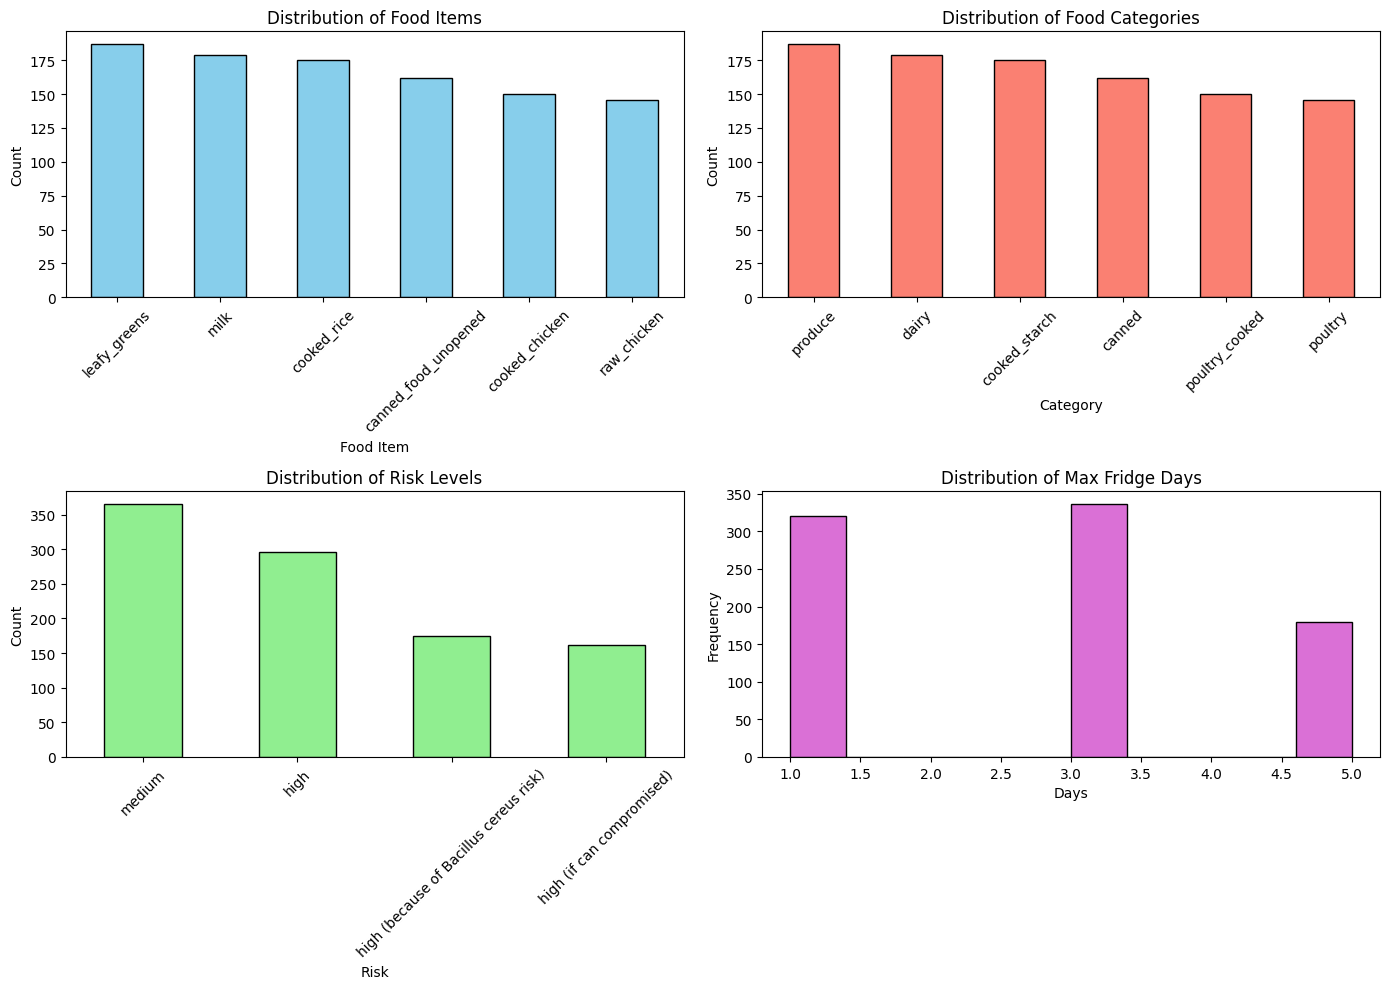

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df['food_item'].value_counts().plot(kind='bar', ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Food Items')
axes[0, 0].set_xlabel('Food Item')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

df['category'].value_counts().plot(kind='bar', ax=axes[0, 1], color='salmon', edgecolor='black')
axes[0, 1].set_title('Distribution of Food Categories')
axes[0, 1].set_xlabel('Category')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

df['risk'].value_counts().plot(kind='bar', ax=axes[1, 0], color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Distribution of Risk Levels')
axes[1, 0].set_xlabel('Risk')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

df['max_fridge_days'].dropna().plot(kind='hist', ax=axes[1, 1], bins=10, color='orchid', edgecolor='black')
axes[1, 1].set_title('Distribution of Max Fridge Days')
axes[1, 1].set_xlabel('Days')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

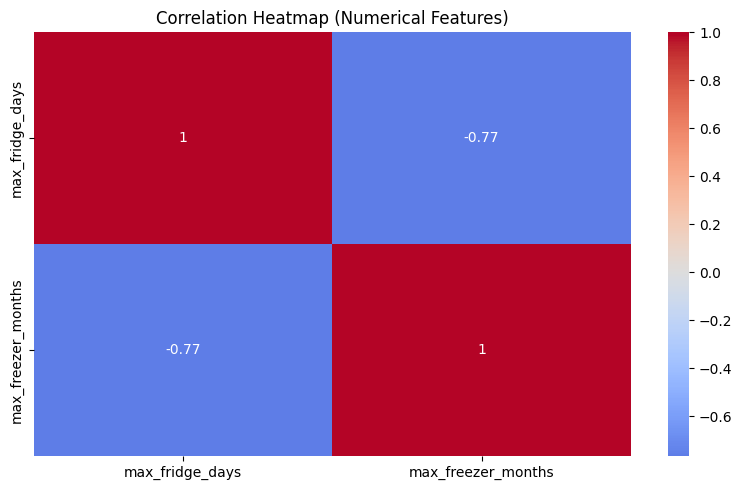


Cross-tabulation: Food Item vs Risk Level
risk                  high  high (because of Bacillus cereus risk)  \
food_item                                                            
canned_food_unopened     0                                       0   
cooked_chicken         150                                       0   
cooked_rice              0                                     175   
leafy_greens             0                                       0   
milk                     0                                       0   
raw_chicken            146                                       0   

risk                  high (if can compromised)  medium  
food_item                                                
canned_food_unopened                        162       0  
cooked_chicken                                0       0  
cooked_rice                                   0       0  
leafy_greens                                  0     187  
milk                                          0 

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
numeric_cols = df[['max_fridge_days', 'max_freezer_months']].dropna()
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap (Numerical Features)')
plt.tight_layout()
plt.show()

print("\nCross-tabulation: Food Item vs Risk Level")
print(pd.crosstab(df['food_item'], df['risk']))

In [8]:
df_model = df.copy()
total_rows = len(df_model)
rows_with_missing = df_model.isnull().any(axis=1).sum()

prop_rows_missing = rows_with_missing / total_rows

print(f"Rows with ≥1 missing value: {rows_with_missing}")
print(f"Proportion of rows with missing values: {prop_rows_missing:.2%}")

Rows with ≥1 missing value: 162
Proportion of rows with missing values: 16.22%


In [9]:
df_model = df.copy()

df_model['storage_temperature_C'] = df_model['storage_temperature_C'].replace('<=4h', '<=4')

df_model['max_fridge_days'].fillna(df_model['max_fridge_days'].mode()[0], inplace=True)
df_model['max_freezer_months'].fillna(df_model['max_freezer_months'].mode()[0], inplace=True)

print("Imputasi missing values dengan MODE:")
print(f"  max_fridge_days mode = {df['max_fridge_days'].mode()[0]}")
print(f"  max_freezer_months mode = {df['max_freezer_months'].mode()[0]}")

df_model['Food_Spoiled'] = df_model['risk'].apply(
    lambda x: 1 if 'high' in x.lower() else 0
)

print(f"\nTarget variable distribution:")
print(df_model['Food_Spoiled'].value_counts())
print(f"\nSpoiled ratio: {df_model['Food_Spoiled'].mean():.2%}")
print(f"Missing values: {df_model.isnull().sum().sum()}")

Imputasi missing values dengan MODE:
  max_fridge_days mode = 3.0
  max_freezer_months mode = 8.0

Target variable distribution:
Food_Spoiled
1    633
0    366
Name: count, dtype: int64

Spoiled ratio: 63.36%
Missing values: 0


Build Feature Matrix

In [10]:
feature_cols = ['max_fridge_days', 'max_freezer_months']

X = df_model[feature_cols]
y = df_model['Food_Spoiled']

print(f"Feature matrix shape: {X.shape}")
print(f"Features: {list(X.columns)}")

print(f"\nData per kombinasi fitur:")
combo = df_model.groupby(feature_cols)['Food_Spoiled'].value_counts().unstack(fill_value=0)
combo.columns = ['Not Spoiled', 'Spoiled']
combo['Total'] = combo.sum(axis=1)
print(combo)

Feature matrix shape: (999, 2)
Features: ['max_fridge_days', 'max_freezer_months']

Data per kombinasi fitur:
                                    Not Spoiled  Spoiled  Total
max_fridge_days max_freezer_months                             
1.0             6.0                           0      175    175
                12.0                          0      146    146
3.0             4.0                           0      150    150
                8.0                         187      162    349
5.0             1.0                         179        0    179


Train, Test, & Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTarget distribution in train:")
print(y_train.value_counts(normalize=True).round(4))

Training set: 799 samples
Test set:     200 samples

Target distribution in train:
Food_Spoiled
1    0.6333
0    0.3667
Name: proportion, dtype: float64


Training Model

In [12]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]
print("Logistic Regression trained")

Logistic Regression trained


In [13]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
print("Random Forest trained")

Random Forest trained


In [14]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]
print("Gradient Boosting trained")

Gradient Boosting trained


In [15]:
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_prob = svm_model.predict_proba(X_test_scaled)[:, 1]
print("SVM (RBF kernel) trained")

SVM (RBF kernel) trained


In [16]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]
print("KNN (k=5) trained")

KNN (k=5) trained


In [17]:
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]
print("Decision Tree trained")

Decision Tree trained


In [18]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
nb_pred = nb_model.predict(X_test_scaled)
nb_prob = nb_model.predict_proba(X_test_scaled)[:, 1]
print("Naive Bayes trained")

Naive Bayes trained


Stratified K-Fold Cross-Validation

In [19]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Logistic Regression': (LogisticRegression(random_state=42, max_iter=1000), True),
    'Random Forest': (RandomForestClassifier(n_estimators=100, random_state=42), False),
    'Gradient Boosting': (GradientBoostingClassifier(n_estimators=100, random_state=42), False),
    'SVM (RBF)': (SVC(kernel='rbf', probability=True, random_state=42), True),
    'KNN (k=5)': (KNeighborsClassifier(n_neighbors=5), True),
    'Decision Tree': (DecisionTreeClassifier(random_state=42, max_depth=10), False),
    'Naive Bayes': (GaussianNB(), True)
}

cv_results = []

print("Running Stratified K-Fold Cross-Validation (5 folds)...")

for name, (model, needs_scaling) in models_cv.items():
    X_cv = X_train_scaled if needs_scaling else X_train


    accuracy_cv = cross_val_score(model, X_cv, y_train, cv=skf, scoring='accuracy')
    precision_cv = cross_val_score(model, X_cv, y_train, cv=skf, scoring='precision')
    recall_cv = cross_val_score(model, X_cv, y_train, cv=skf, scoring='recall')
    f1_cv = cross_val_score(model, X_cv, y_train, cv=skf, scoring='f1')
    roc_auc_cv = cross_val_score(model, X_cv, y_train, cv=skf, scoring='roc_auc')

    cv_results.append({
        'Model': name,
        'Accuracy (CV)': accuracy_cv.mean(),
        'Accuracy (Std)': accuracy_cv.std(),
        'Precision (CV)': precision_cv.mean(),
        'Recall (CV)': recall_cv.mean(),
        'F1-Score (CV)': f1_cv.mean(),
        'F1 (Std)': f1_cv.std(),
        'ROC-AUC (CV)': roc_auc_cv.mean()
    })

    print(f"{name:20} - F1: {f1_cv.mean():.4f} (±{f1_cv.std():.4f})")

cv_results_df = pd.DataFrame(cv_results).set_index('Model')
print("CROSS-VALIDATION RESULTS SUMMARY\n")
print(cv_results_df.round(4).to_string())
print(f"\nBest model (CV F1-Score): {cv_results_df['F1-Score (CV)'].idxmax()}")

Running Stratified K-Fold Cross-Validation (5 folds)...
Logistic Regression  - F1: 0.8489 (±0.0130)
Random Forest        - F1: 0.8484 (±0.0204)
Gradient Boosting    - F1: 0.8484 (±0.0204)
SVM (RBF)            - F1: 0.8484 (±0.0204)
KNN (k=5)            - F1: 0.8560 (±0.0202)
Decision Tree        - F1: 0.8484 (±0.0204)
Naive Bayes          - F1: 0.8726 (±0.0131)
CROSS-VALIDATION RESULTS SUMMARY

                     Accuracy (CV)  Accuracy (Std)  Precision (CV)  Recall (CV)  F1-Score (CV)  F1 (Std)  ROC-AUC (CV)
Model                                                                                                                 
Logistic Regression         0.8135          0.0193          0.9015       0.8362         0.8489    0.0130        0.9336
Random Forest               0.8336          0.0197          1.0000       0.7372         0.8484    0.0204        0.9336
Gradient Boosting           0.8336          0.0197          1.0000       0.7372         0.8484    0.0204        0.9336
SVM (RB

Evaluate Model

In [20]:
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

results = [
    evaluate_model('Logistic Regression', y_test, lr_pred, lr_prob),
    evaluate_model('Random Forest', y_test, rf_pred, rf_prob),
    evaluate_model('Gradient Boosting', y_test, gb_pred, gb_prob),
    evaluate_model('SVM (RBF)', y_test, svm_pred, svm_prob),
    evaluate_model('KNN (k=5)', y_test, knn_pred, knn_prob),
    evaluate_model('Decision Tree', y_test, dt_pred, dt_prob),
    evaluate_model('Naive Bayes', y_test, nb_pred, nb_prob)
]

results_df = pd.DataFrame(results).set_index('Model')
print("MODEL COMPARISON TABLE (Test Set Performance)\n")
print(results_df.round(4).to_string())
print(f"\nBest model (F1-Score): {results_df['F1-Score'].idxmax()}")
print(f"Best F1-Score: {results_df['F1-Score'].max():.4f}")

MODEL COMPARISON TABLE (Test Set Performance)

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression     0.855     1.0000  0.7717    0.8711    0.939
Random Forest           0.855     1.0000  0.7717    0.8711    0.939
Gradient Boosting       0.855     1.0000  0.7717    0.8711    0.939
SVM (RBF)               0.855     1.0000  0.7717    0.8711    0.939
KNN (k=5)               0.805     0.7651  1.0000    0.8669    0.939
Decision Tree           0.855     1.0000  0.7717    0.8711    0.939
Naive Bayes             0.805     0.7651  1.0000    0.8669    0.838

Best model (F1-Score): Logistic Regression
Best F1-Score: 0.8711


Classification Report: Logistic Regression
              precision    recall  f1-score   support

 Not Spoiled       0.72      1.00      0.83        73
     Spoiled       1.00      0.77      0.87       127

    accuracy                           0.85       200
   macro avg       0.86      0.89      0.85       200
weighted avg       0.90      0.85      0.86       200

Classification Report: Random Forest
              precision    recall  f1-score   support

 Not Spoiled       0.72      1.00      0.83        73
     Spoiled       1.00      0.77      0.87       127

    accuracy                           0.85       200
   macro avg       0.86      0.89      0.85       200
weighted avg       0.90      0.85      0.86       200

Classification Report: Gradient Boosting
              precision    recall  f1-score   support

 Not Spoiled       0.72      1.00      0.83        73
     Spoiled       1.00      0.77      0.87       127

    accuracy                           0.85       200
   macr

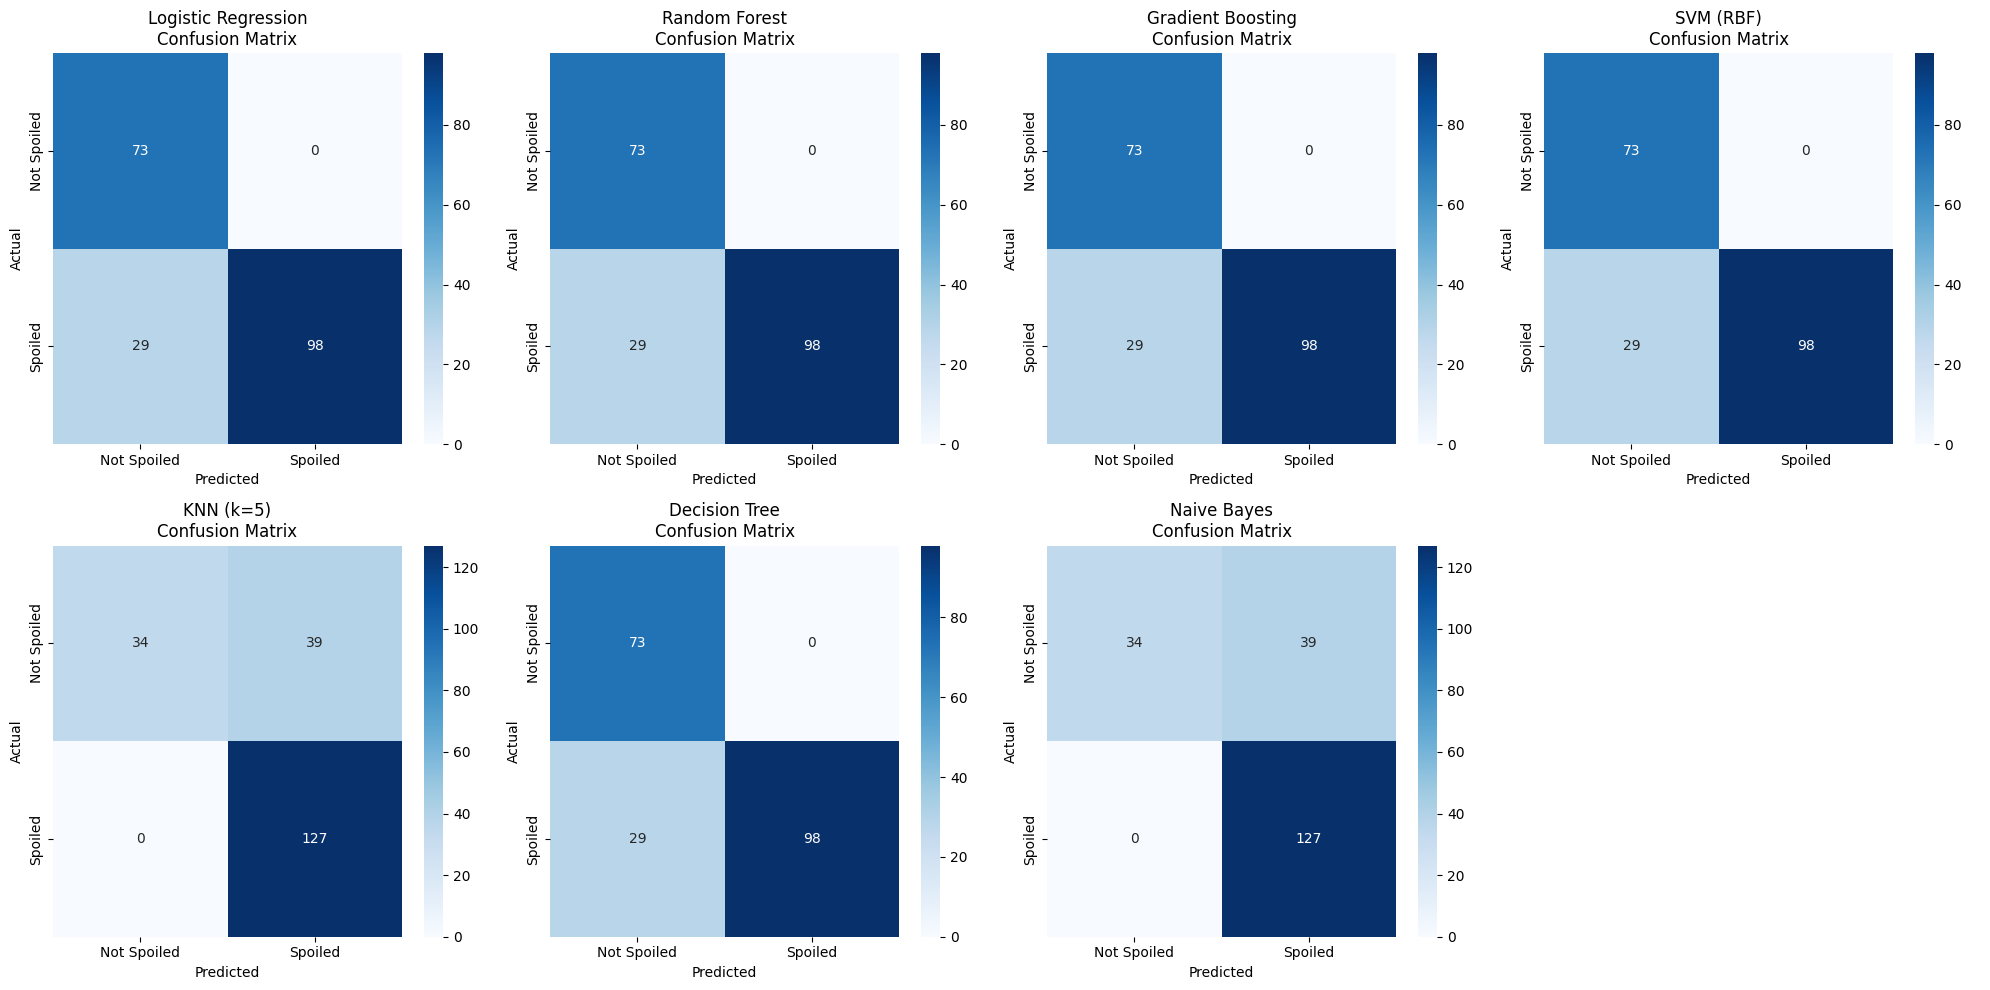

In [21]:
models = {
    'Logistic Regression': (lr_pred, lr_prob),
    'Random Forest': (rf_pred, rf_prob),
    'Gradient Boosting': (gb_pred, gb_prob),
    'SVM (RBF)': (svm_pred, svm_prob),
    'KNN (k=5)': (knn_pred, knn_prob),
    'Decision Tree': (dt_pred, dt_prob),
    'Naive Bayes': (nb_pred, nb_prob)
}

for name, (pred, prob) in models.items():
    print(f"Classification Report: {name}")
    print(classification_report(y_test, pred, target_names=['Not Spoiled', 'Spoiled']))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (name, (pred, prob)) in enumerate(models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Not Spoiled', 'Spoiled'],
                yticklabels=['Not Spoiled', 'Spoiled'])
    axes[i].set_title(f'{name}\nConfusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

axes[-1].axis('off')

plt.tight_layout()
plt.show()

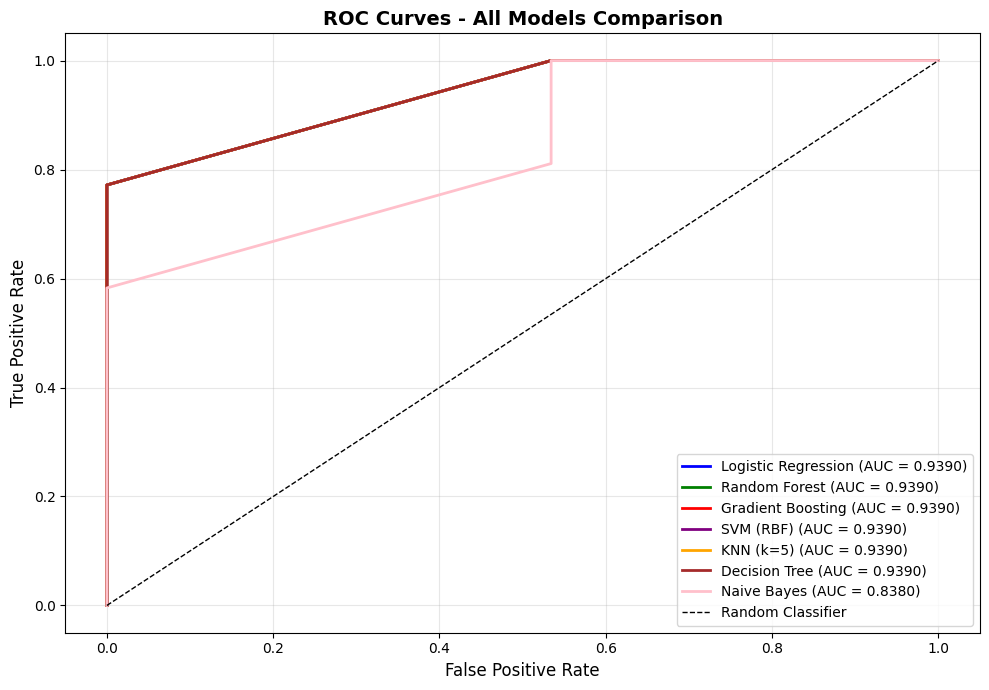

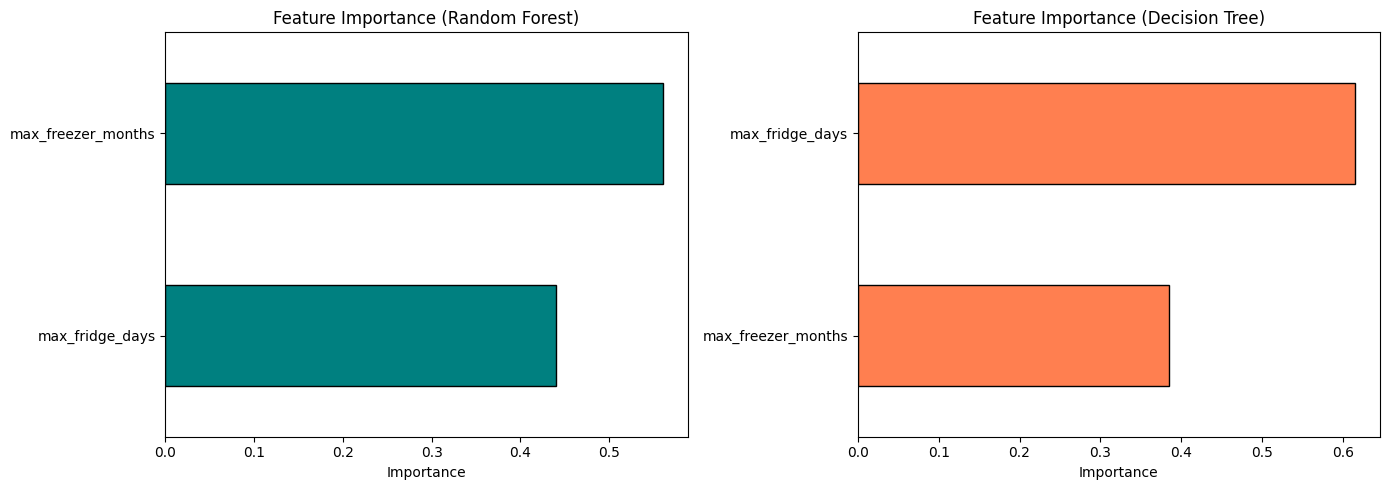

In [22]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'pink']

for i, (name, (pred, prob)) in enumerate(models.items()):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.4f})', color=colors[i], linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - All Models Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

feat_imp_rf = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
feat_imp_rf.plot(kind='barh', color='teal', edgecolor='black', ax=axes[0])
axes[0].set_title('Feature Importance (Random Forest)')
axes[0].set_xlabel('Importance')

feat_imp_dt = pd.Series(dt_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
feat_imp_dt.plot(kind='barh', color='coral', edgecolor='black', ax=axes[1])
axes[1].set_title('Feature Importance (Decision Tree)')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

Comprehensive Model Comparison

COMPREHENSIVE MODEL COMPARISON

Test Set vs Cross-Validation Performance:

                     Accuracy  Accuracy (CV)  Precision  Recall  F1-Score  F1-Score (CV)  F1 (Std)  ROC-AUC
Model                                                                                                      
Logistic Regression     0.855         0.8135     1.0000  0.7717    0.8711         0.8489    0.0130    0.939
Random Forest           0.855         0.8336     1.0000  0.7717    0.8711         0.8484    0.0204    0.939
Gradient Boosting       0.855         0.8336     1.0000  0.7717    0.8711         0.8484    0.0204    0.939
SVM (RBF)               0.855         0.8336     1.0000  0.7717    0.8711         0.8484    0.0204    0.939
KNN (k=5)               0.805         0.8323     0.7651  1.0000    0.8669         0.8560    0.0202    0.939
Decision Tree           0.855         0.8336     1.0000  0.7717    0.8711         0.8484    0.0204    0.939
Naive Bayes             0.805         0.8147     0.7651  1.00

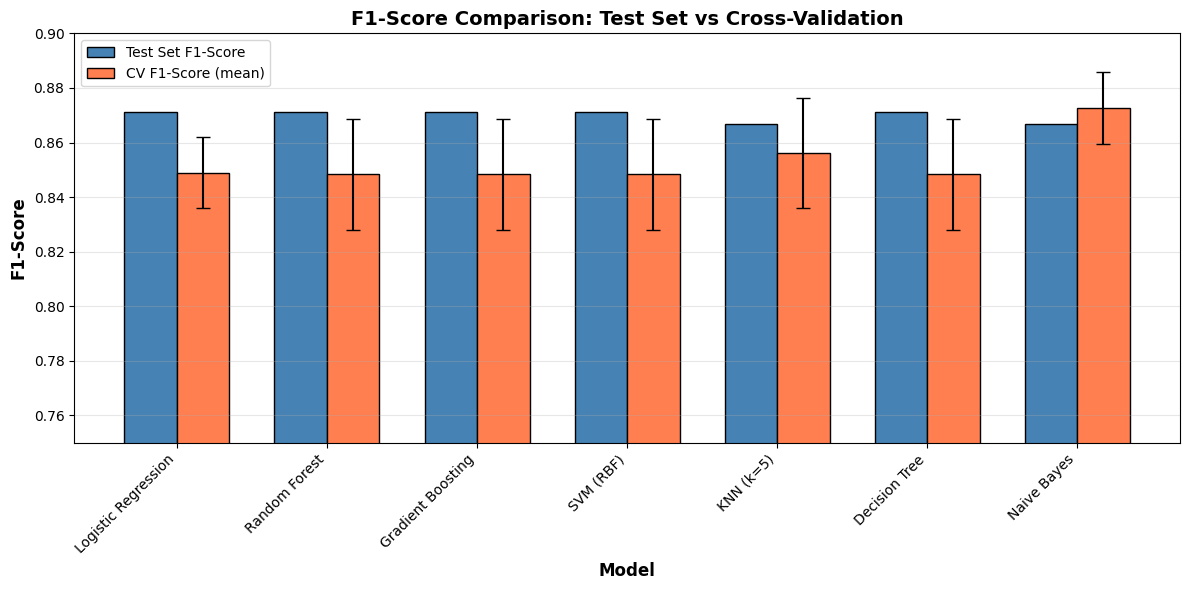

MODEL RANKING (based on Cross-Validation F1-Score):
1. Naive Bayes               - CV F1: 0.8726 (±0.0131), Test F1: 0.8669
2. KNN (k=5)                 - CV F1: 0.8560 (±0.0202), Test F1: 0.8669
3. Logistic Regression       - CV F1: 0.8489 (±0.0130), Test F1: 0.8711
4. Gradient Boosting         - CV F1: 0.8484 (±0.0204), Test F1: 0.8711
5. Random Forest             - CV F1: 0.8484 (±0.0204), Test F1: 0.8711
6. SVM (RBF)                 - CV F1: 0.8484 (±0.0204), Test F1: 0.8711
7. Decision Tree             - CV F1: 0.8484 (±0.0204), Test F1: 0.8711


In [23]:
comparison_df = results_df.copy()
comparison_df['F1-Score (CV)'] = cv_results_df['F1-Score (CV)']
comparison_df['F1 (Std)'] = cv_results_df['F1 (Std)']
comparison_df['Accuracy (CV)'] = cv_results_df['Accuracy (CV)']

comparison_df = comparison_df[['Accuracy', 'Accuracy (CV)', 'Precision', 'Recall',
                                 'F1-Score', 'F1-Score (CV)', 'F1 (Std)', 'ROC-AUC']]


print("COMPREHENSIVE MODEL COMPARISON")
print("\nTest Set vs Cross-Validation Performance:\n")
print(comparison_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['F1-Score'], width,
               label='Test Set F1-Score', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, comparison_df['F1-Score (CV)'], width,
               label='CV F1-Score (mean)', color='coral', edgecolor='black')

ax.errorbar(x + width/2, comparison_df['F1-Score (CV)'],
            yerr=comparison_df['F1 (Std)'], fmt='none',
            color='black', capsize=5, linewidth=1.5)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('F1-Score Comparison: Test Set vs Cross-Validation', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index, rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0.75, 0.90])

plt.tight_layout()
plt.show()

print("MODEL RANKING (based on Cross-Validation F1-Score):")
ranking = comparison_df.sort_values('F1-Score (CV)', ascending=False)
for i, (model, row) in enumerate(ranking.iterrows(), 1):
    print(f"{i}. {model:25} - CV F1: {row['F1-Score (CV)']:.4f} (±{row['F1 (Std)']:.4f}), "
          f"Test F1: {row['F1-Score']:.4f}")

FINAL CONCLUSION & MODEL RECOMMENDATION
-Total models tested: 7
-Evaluation methods: Test set (20%) + Stratified 5-Fold Cross-Validation
-Dataset: 999 samples, 2 features

-Test Set F1-Score:     0.8669
-CV F1-Score (mean):    0.8726 ± 0.0131
-Test Set Accuracy:     0.8050
-CV Accuracy (mean):    0.8147
-Precision:             0.7651
-Recall:                1.0000
-ROC-AUC:               0.8380

PERFORMANCE ANALYSIS:
-Performance varies across models (F1 range: 0.0242)
-Naive Bayes shows superior generalization
-Cross-validation confirms consistent performance

Menyimpan Model

In [25]:
import joblib
joblib.dump(lr_model, "logistic_regression.pkl")
joblib.dump(rf_model, "random_forest.pkl")
joblib.dump(gb_model, "gradient_boosting.pkl")
joblib.dump(svm_model, "svm_rbf.pkl")
joblib.dump(knn_model, "knn_k5.pkl")
joblib.dump(dt_model, "decision_tree.pkl")
joblib.dump(nb_model, "naive_bayes.pkl")


['naive_bayes.pkl']